In [41]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ==========================================
# 1. DATA prep
# ==========================================

# Load the filtered dataset (articles tagged with data privacy/personal data)
filtered_articles_df = pd.read_csv('./data/Quant_GDELT_Dataset_DataFilters.csv', parse_dates=["DateOnly"])

# Load the unfiltered dataset (control group)
control_articles_df = pd.read_csv('./data/Quant_GDELT_Dataset_Unfiltered.csv', parse_dates=["DateOnly"])

# Create a binary/boolean flag 'Is_Filtered'
# 1 = Privacy/Personal Data , 0 = Control 
filtered_articles_df['Is_Filtered'] = 1
control_articles_df['Is_Filtered'] = 0

# Join both datasets for regression analysis
combined_articles_df = pd.concat([filtered_articles_df, control_articles_df], ignore_index=True)


combined_articles_df.head()

,ParsedDate,DateOnly,NewsSource,SourceURL,Headline,SentimentScore,Positive,Negative,Polarity,ActivityDensity,SelfDensity,MatchedThemes,ThemeMatchCount,SyndicationCount,Is_Filtered,DATE
0,44783.28125,2022-08-10,investegate.co.uk,https://www.investegate.co.uk/prudential-plc--...,Investegate |Prudential PLC Announcements | Pr...,-3.678024,2.337559,6.015584,8.353143,20.040940,0.059429,PERSONAL_DATA_PROTECTION|DATA_SECURITY|DATA_PR...,3,1.0,1,NaN
1,45702.39583,2025-02-14,investegate.co.uk:443,https://www.investegate.co.uk:443/announcement...,NWM Plc 2024 Annual Report | Company Announce...,-2.635202,3.485742,6.120944,9.606686,22.463127,0.073746,PERSONAL_DATA_PROTECTION|DATA_SECURITY|DATA_PR...,3,1.0,1,NaN
2,45338.31250,2024-02-16,investegate.co.uk:443,https://www.investegate.co.uk:443/announcement...,Investegate | Company Announcement,-2.652531,3.469329,6.121860,9.591188,21.550266,0.074254,PERSONAL_DATA_PROTECTION|DATA_SECURITY|DATA_PR...,3,4.0,1,NaN
3,45000.31250,2023-03-15,investegate.co.uk,https://www.investegate.co.uk/prudential-plc--...,Investegate |Prudential PLC Announcements | Pr...,-3.265390,2.522326,5.787716,8.310042,19.762765,0.074988,PERSONAL_DATA_PROTECTION|DATA_SECURITY|DATA_PR...,3,1.0,1,NaN
4,44974.41667,2023-02-17,investegate.co.uk,https://www.investegate.co.uk/nat.westminster-...,Investegate |Nat.Westminster Bk Announcements ...,-2.429497,3.240761,5.670258,8.911019,21.874061,0.060094,PERSONAL_DATA_PROTECTION|DATA_SECURITY,2,1.0,1,NaN


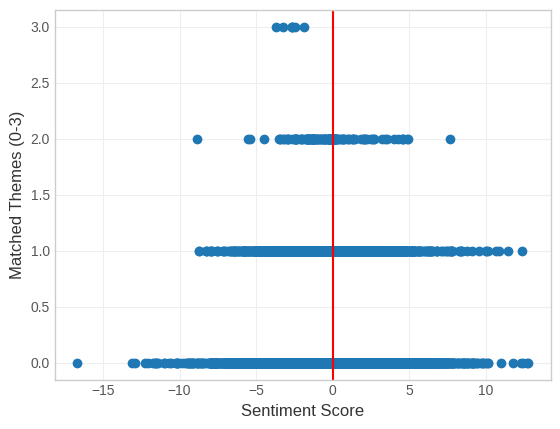

In [42]:
plt.scatter(y = combined_articles_df['ThemeMatchCount'], x = combined_articles_df['SentimentScore'])
plt.xlabel('Sentiment Score')
plt.ylabel('Matched Themes (0-3)')
plt.axvline(x=0, color='r', linestyle='-')
plt.show();

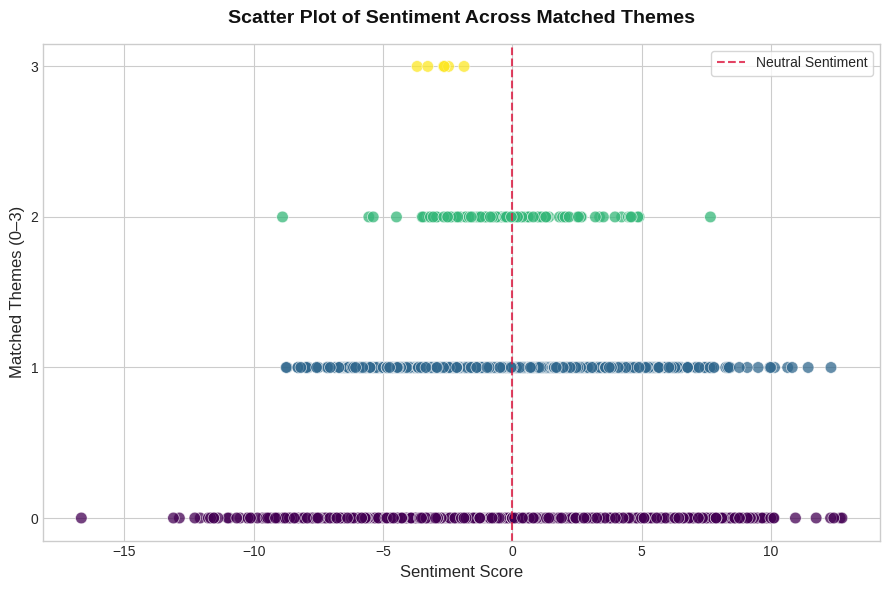

In [43]:
plt.style.use('seaborn-v0_8-whitegrid') #nice grid

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    combined_articles_df['SentimentScore'],
    combined_articles_df['ThemeMatchCount'],
    c=combined_articles_df['ThemeMatchCount'],
    cmap='viridis', # colours
    s=70,#size
    alpha=0.75,#opacity
    edgecolors='white',#circle outline
    linewidth=0.5
)

# 0 reference line
ax.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5, alpha=0.8, label='Neutral Sentiment')

# Labels & title
ax.set_xlabel('Sentiment Score', fontsize=12,fontweight='medium' )
ax.set_ylabel('Matched Themes (0–3)', fontsize=12, fontweight='medium')
ax.set_title('Scatter Plot of Sentiment Across Matched Themes', fontsize=14, fontweight='bold', pad=15)

# Y-axis as integer ticks since it's a count / no halves
ax.set_yticks(np.arange(0, 4, 1))



ax.legend(frameon=True, loc='upper right') # 0 line legend
ax.grid(True)# adds grid

plt.tight_layout() #adjusts layout for clarity
plt.show()

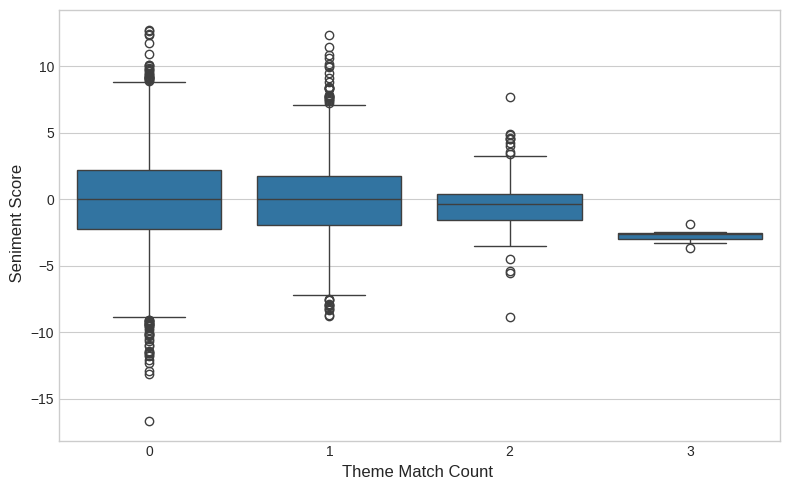

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=combined_articles_df,y='SentimentScore',x='ThemeMatchCount')

plt.xlabel('Theme Match Count ')
plt.ylabel(' Seniment Score')
plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# 2. OLS REGRESSION ANALYSIS
# ==========================================
# Determine if articles tagged with data privacy/personal data
# have a significantly different 'SentimentScore' score compared to the control dataset,
# controlling for month-year fixed effects to isolate the Is_Filtered effect.

# Create a month-year period variable as a categorical control
combined_articles_df['MonthYear'] = combined_articles_df['DateOnly'].dt.to_period('M').astype(str)

# Define the regression formula:
# C(MonthYear) treats each month-year as a dummy variable (one dropped as reference)
regression_formula = "SentimentScore ~ Is_Filtered + C(MonthYear)"

# Fit the OLS model
sentiment_model = sm.formula.ols(formula=regression_formula, data=combined_articles_df)
fitted_model = sentiment_model.fit()
print(fitted_model.summary())


                            OLS Regression Results                            
Dep. Variable:         SentimentScore   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.242
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           1.37e-09
Time:                        20:22:57   Log-Likelihood:                -16251.
No. Observations:                6317   AIC:                         3.267e+04
Df Residuals:                    6234   BIC:                         3.323e+04
Df Model:                          82                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [46]:
# ==========================================
# 3. OLS REGRESSION FURTHER ANALYSIS AND FORMATTED RESULT
# ==========================================

combined_articles_df['MonthYear'] = combined_articles_df['DateOnly'].dt.to_period('M').astype(str)

score_columns = ["SentimentScore", "Positive", "Negative", "Polarity", "ActivityDensity", "SelfDensity"]

results = []#empty list

for outcome in score_columns:
    formula = f"{outcome} ~ Is_Filtered + ThemeMatchCount + C(MonthYear)"
    model = sm.formula.ols(formula=formula, data=combined_articles_df).fit(cov_type='HC3')#heteroskedacity robustness for error variance in sentiment data
    
    results.append({
        "Outcome":     outcome,
        "Coef":        model.params['Is_Filtered'],
        "Std_Err":     model.bse['Is_Filtered'],
        "p_value":     model.pvalues['Is_Filtered'],
        "CI_Lower":    model.conf_int().loc['Is_Filtered', 0],
        "CI_Upper":    model.conf_int().loc['Is_Filtered', 1],
        "R_squared":   model.rsquared,
        "N":           int(model.nobs)
    })

results_df = pd.DataFrame(results).set_index("Outcome")

# Round for readability
results_df = results_df.round(4)

# Flag significant results
results_df['Significant'] = results_df['p_value'].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
)

print("Effect of Is_Filtered on all Variables")
print("ThemeMatchCount + Month-Year Fixed Effects")
print(results_df.to_string())

Effect of Is_Filtered on all Variables
ThemeMatchCount + Month-Year Fixed Effects
                   Coef  Std_Err  p_value  CI_Lower  CI_Upper  R_squared     N Significant
Outcome                                                                                   
SentimentScore   0.3334   0.2129   0.1174   -0.0840    0.7508     0.0290  6317            
Positive        -0.0773   0.1182   0.5133   -0.3090    0.1544     0.0337  6317            
Negative        -0.4107   0.1685   0.0148   -0.7410   -0.0804     0.0268  6317          **
Polarity        -0.4880   0.1985   0.0140   -0.8771   -0.0988     0.0305  6317          **
ActivityDensity -1.2873   0.2401   0.0000   -1.7578   -0.8169     0.0974  6317         ***
SelfDensity     -0.0855   0.1551   0.5813   -0.3895    0.2185     0.1054  6317            


In [47]:
# ==========================================
# 3.CHART STYLING
# ==========================================

plt.rcParams.update({
    "figure.facecolor": "#ffffff",      
    "axes.facecolor":   "#ffffff",      
    "axes.edgecolor":   "#cccccc",      
    "axes.labelcolor":  "#333333",      
    "axes.titlecolor":  "#111111",      
    "xtick.color":      "#555555",      
    "ytick.color":      "#555555",
    "text.color":       "#333333",
    "grid.color":       "#eeeeee",      
    "grid.linewidth":   0.8,
    "font.family":      "sans-serif",   
    "axes.titlesize":   14,
    "axes.labelsize":   12,
})

# Columns representing different score metrics
score_columns = [
    "SentimentScore", "Positive", "Negative",
    "Polarity", "ActivityDensity", "SelfDensity"
]

ACCENT_COLORS = [
    "#1f77b4", # Blue
    "#ff7f0e", # Orange
    "#2ca02c", # Green
    "#d62728", # Red
    "#9467bd", # Purple
    "#8c564b"  # Brown
]




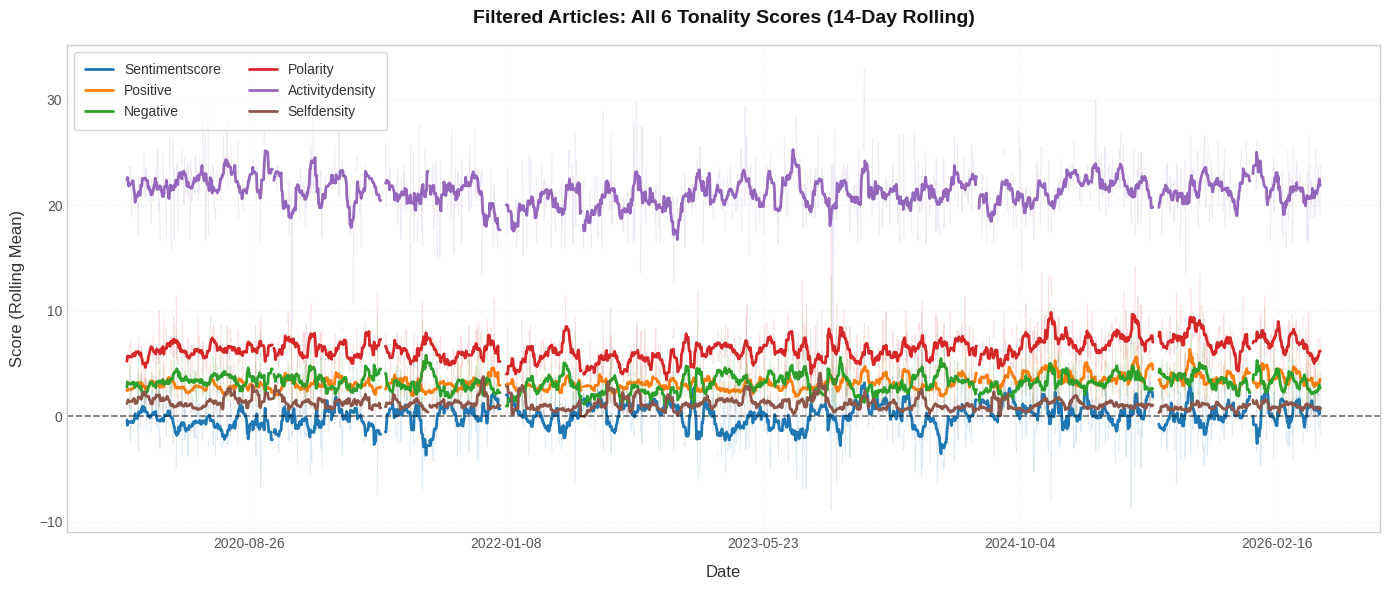

Saved → chart4_multi_series_rolling_filtered.png


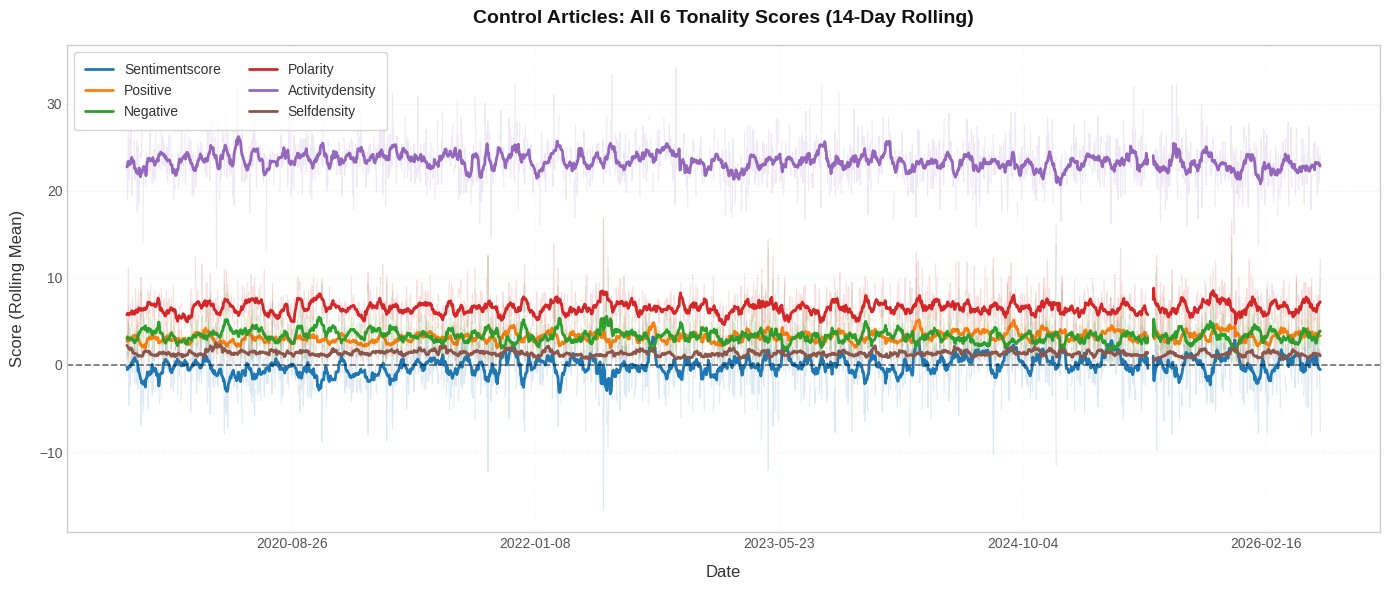

Saved → chart4_multi_series_rolling_control.png


In [48]:
# ==========================================
# 4. MULTI-SERIES TONALITY CHART
# ==========================================
def plot_multi_series_rolling(dataframe, score_columns, dataset_name="Filtered", window_days=14):
    """
    Plots a rolling average for multiple tonality scores on a single chart.
    Updated styling: Removes the dark background, replacing it with a clean, 
    highly readable light aesthetic. Retains distinct line colors for easy comparison.
    """
    # Calculate the daily mean for all specified score columns
    daily_avg_scores = dataframe.set_index("DateOnly")[score_columns].resample("D").mean()
    
    # Apply rolling average to smooth out the daily noise
    rolling_avg_scores = daily_avg_scores.rolling(window=window_days, center=True, min_periods=3).mean()
 
    # Initialize the figure
    fig, ax = plt.subplots(figsize=(14, 6))
 
    # Plot each score metric with its designated accent color
    for col, color in zip(score_columns, ACCENT_COLORS):
        # Plot the raw daily data as a very faint line behind the main trend
        ax.plot(daily_avg_scores.index, daily_avg_scores[col], color=color, alpha=0.15, linewidth=0.8)
        
        # Plot the smoothed rolling average as a bold, clear line
        ax.plot(rolling_avg_scores.index, rolling_avg_scores[col], color=color, linewidth=2.0,
                label=col.replace("_", " ").title())
 
    # Add a clear neutral reference line at 0 
    ax.axhline(0, color="#111111", linewidth=1.2, linestyle="--", alpha=0.6)
 
    # Chart formatting
    ax.set_title(f"{dataset_name} Articles: All 6 Tonality Scores ({window_days}-Day Rolling)",
                 pad=16, fontweight="bold", fontsize=14)
    ax.set_xlabel("Date", labelpad=10)
    ax.set_ylabel("Score (Rolling Mean)", labelpad=10)
 
    # Format the legend for a light background
    ax.legend(
        frameon=True, fontsize=10, labelcolor="#333333",
        facecolor="#ffffff", edgecolor="#cccccc",
        loc="upper left", ncol=2, borderpad=0.8,
    )
 
    # Add subtle gridlines for readability
    ax.grid(axis="y", alpha=0.5, linestyle="--")
    ax.grid(axis="x", alpha=0.2, linestyle="--")
    ax.xaxis.set_major_locator(ticker.AutoLocator())
 
    # Final layout adjustments and save
    fig.tight_layout()
    
    # Create a filename based on the dataset name
    filename = f"chart4_multi_series_rolling_{dataset_name.lower()}.png"
    fig.savefig(filename, dpi=150, bbox_inches="tight", facecolor="#ffffff")
    plt.show()
    print(f"Saved → {filename}")


# ==========================================
# EXECUTION CALLS
# ==========================================
# 1. Plot the filtered privacy/personal data articles
plot_multi_series_rolling(filtered_articles_df, score_columns, dataset_name="Filtered", window_days=14)

# 2. Plot the unfiltered control group articles
plot_multi_series_rolling(control_articles_df, score_columns, dataset_name="Control", window_days=14)

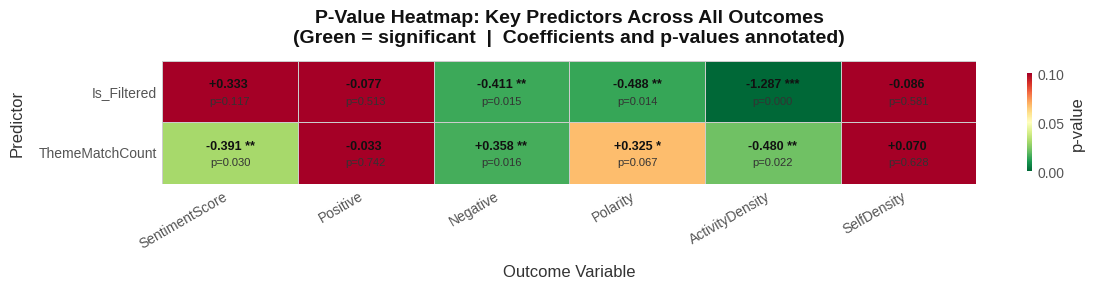

Saved → chart_pvalue_heatmap.png


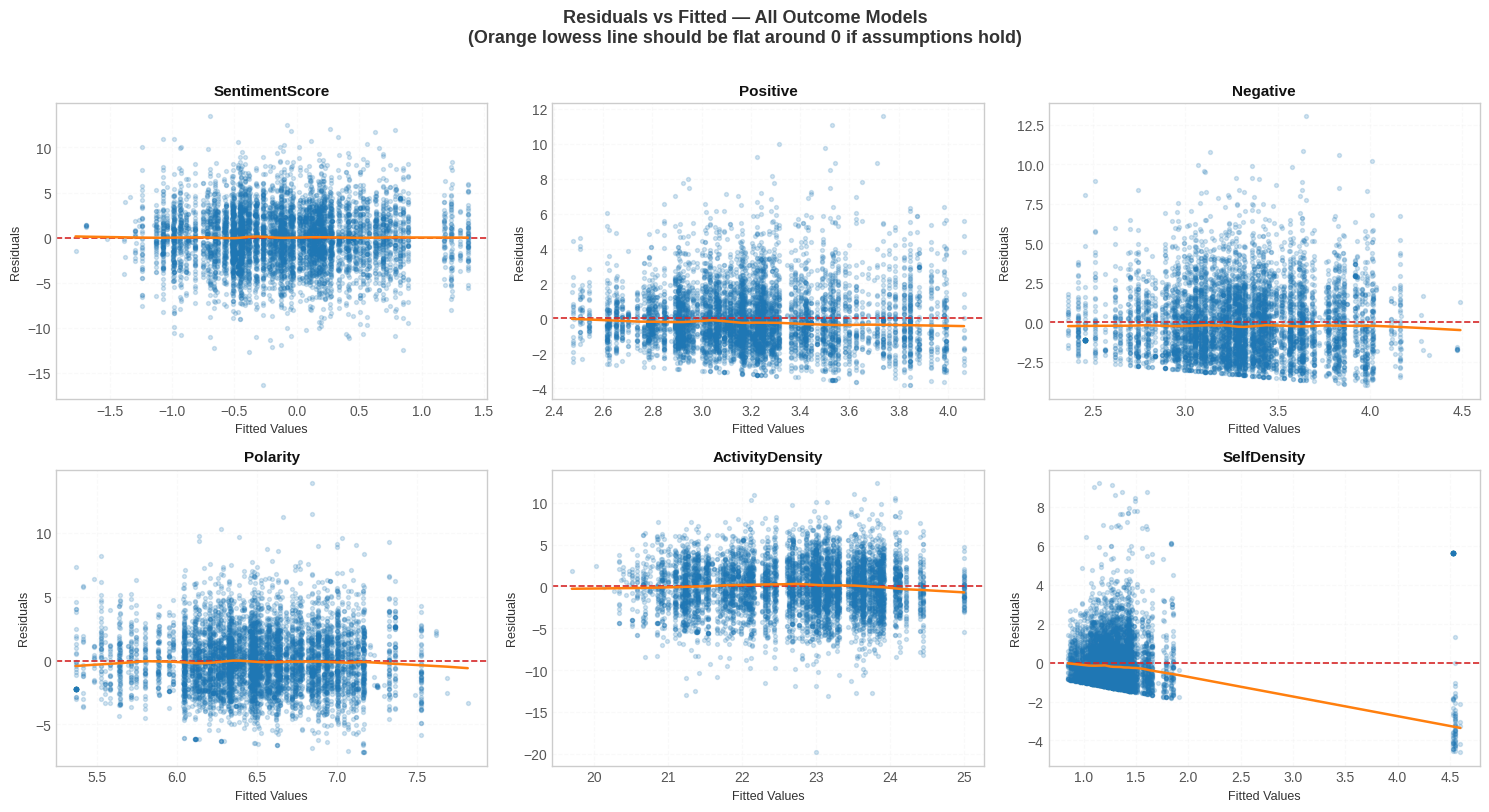

Saved → chart_diag_residuals_vs_fitted.png


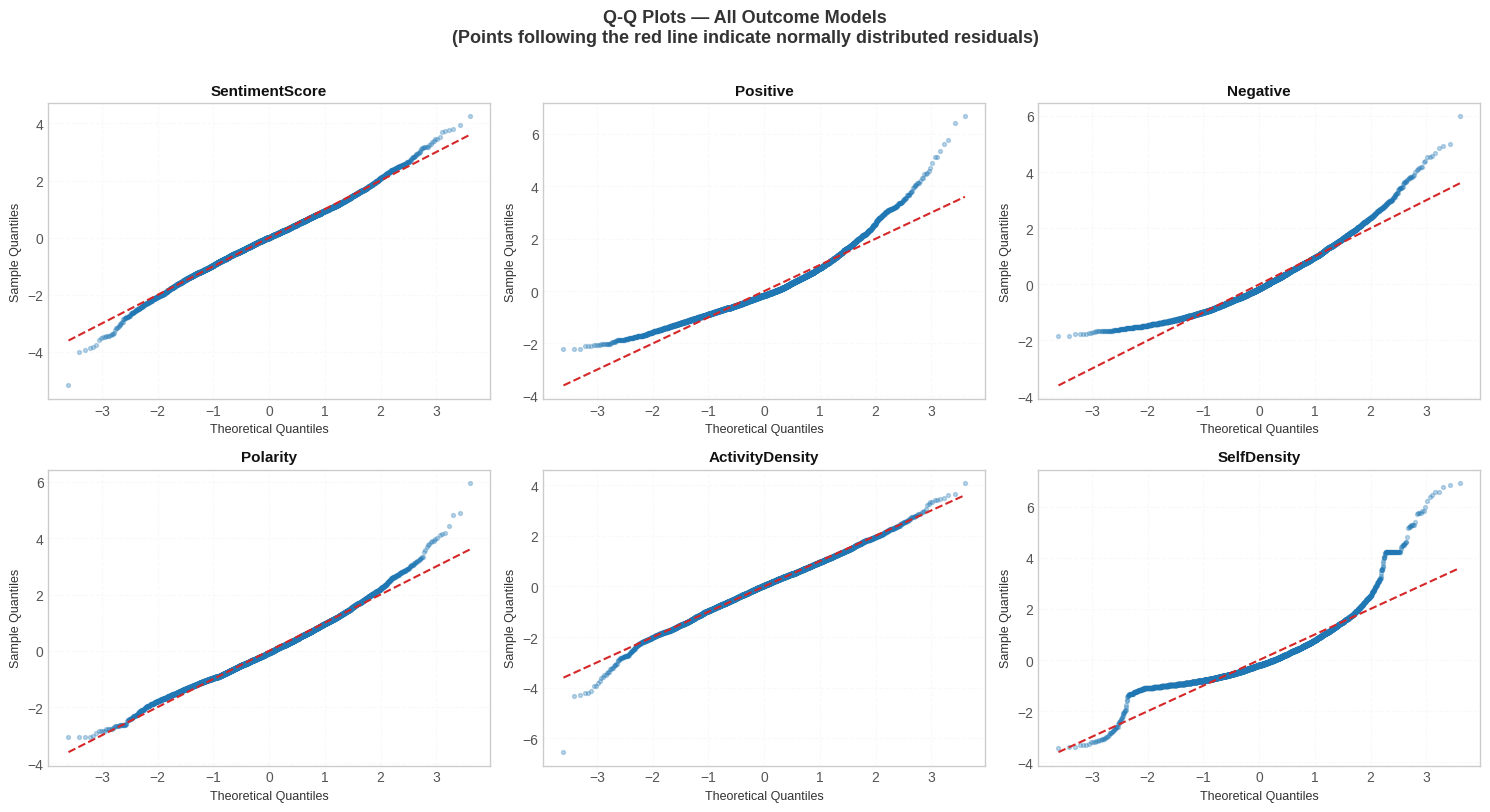

Saved → chart_diag_qq.png


In [49]:
# ==========================================
# 5. REGRESSION VISUALISATIONS
# ==========================================

# Rebuild fitted models as a dict to expose residuals/fitted values for graphs
fitted_models = {}
for outcome in score_columns:
    formula = f"{outcome} ~ Is_Filtered + ThemeMatchCount + C(MonthYear)"
    fitted_models[outcome] = sm.formula.ols(
        formula=formula, data=combined_articles_df
    ).fit(cov_type='HC3')

# ------------------------------------------
# 5B. P-VALUE HEATMAP
# ------------------------------------------
def plot_pvalue_heatmap(fitted_models, score_columns):
    """
    Heatmap of p-values for Is_Filtered and ThemeMatchCount across all outcomes.
    Green = significant, red = not significant.
    """
    key_vars = ["Is_Filtered", "ThemeMatchCount"]

    # Build a p-value matrix: rows = predictors, cols = outcomes
    pval_matrix = pd.DataFrame(index=key_vars, columns=score_columns, dtype=float)
    coef_matrix = pd.DataFrame(index=key_vars, columns=score_columns, dtype=float)

    for outcome in score_columns:
        model = fitted_models[outcome]
        for var in key_vars:
            pval_matrix.loc[var, outcome] = model.pvalues[var]
            coef_matrix.loc[var, outcome] = model.params[var]

    fig, ax = plt.subplots(figsize=(12, 3))

    # green = low p-value (significant), red = high
    sns.heatmap(
        pval_matrix.astype(float),
        annot=False,          
        cmap="RdYlGn_r",
        vmin=0, vmax=0.10,    # Cap at 0.10 so colours are informative 
        linewidths=0.5,
        linecolor="#cccccc",
        ax=ax,
        cbar_kws={"label": "p-value", "shrink": 0.8}
    )

    # Annotate each cell with coefficient and p-value on two lines
    for i, var in enumerate(key_vars):
        for j, outcome in enumerate(score_columns):
            p = pval_matrix.loc[var, outcome]
            c = coef_matrix.loc[var, outcome]
            stars = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
            ax.text(j + 0.5, i + 0.38, f"{c:+.3f} {stars}",
                    ha='center', va='center', fontsize=9, fontweight='bold', color="#111111")
            ax.text(j + 0.5, i + 0.65, f"p={p:.3f}",
                    ha='center', va='center', fontsize=8, color="#333333")

    ax.set_title("P-Value Heatmap: Key Predictors Across All Outcomes\n"
                 "(Green = significant  |  Coefficients and p-values annotated)",
                 fontweight="bold", pad=14)
    ax.set_xlabel("Outcome Variable", labelpad=10)
    ax.set_ylabel("Predictor", labelpad=10)
    ax.set_xticklabels(score_columns, rotation=30, ha='right')
    ax.set_yticklabels(key_vars, rotation=0)

    fig.tight_layout()
    fig.savefig("chart_pvalue_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → chart_pvalue_heatmap.png")

plot_pvalue_heatmap(fitted_models, score_columns)


# ------------------------------------------
# 5C. DIAGNOSTIC PLOTS 
# ------------------------------------------

# --- Residuals vs Fitted ---
def plot_residuals_vs_fitted(fitted_models, score_columns):
    """
    Checks homoskedasticity: residuals should be randomly scattered around 0
    with no clear funnel or curve. Systematic patterns suggest model issues.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, outcome in enumerate(score_columns):
        model   = fitted_models[outcome]
        fitted  = model.fittedvalues
        resids  = model.resid

        axes[i].scatter(fitted, resids, alpha=0.2, s=8, color="#1f77b4")
        axes[i].axhline(0, color="#d62728", linewidth=1.2, linestyle="--")

        # Lowess smoothing line to reveal any trend in residuals
        lowess = sm.nonparametric.lowess(resids, fitted, frac=0.3)
        axes[i].plot(lowess[:, 0], lowess[:, 1], color="#ff7f0e", linewidth=1.8)

        axes[i].set_title(outcome, fontweight="bold", fontsize=11)
        axes[i].set_xlabel("Fitted Values", fontsize=9)
        axes[i].set_ylabel("Residuals", fontsize=9)
        axes[i].grid(alpha=0.3, linestyle="--")

    fig.suptitle("Residuals vs Fitted — All Outcome Models\n"
                 "(Orange lowess line should be flat around 0 if assumptions hold)",
                 fontweight="bold", fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig("chart_diag_residuals_vs_fitted.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → chart_diag_residuals_vs_fitted.png")

plot_residuals_vs_fitted(fitted_models, score_columns)


# --- Q-Q Plot ---
def plot_qq(fitted_models, score_columns):
    """
    Checks normality of residuals. Points should follow the diagonal reference line.
    Heavy tails (S-curve) or skew indicate non-normal residuals.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, outcome in enumerate(score_columns):
        resids = fitted_models[outcome].resid

        # sm.qqplot returns a figure; we extract its data and replot onto our subplot
        qq_fig  = sm.qqplot(resids, line='s', fit=True)
        qq_ax   = qq_fig.axes[0]
        points  = qq_ax.get_lines()[0]
        ref     = qq_ax.get_lines()[1]
        plt.close(qq_fig)   # Close the auto-generated figure

        axes[i].scatter(points.get_xdata(), points.get_ydata(),
                        alpha=0.3, s=8, color="#1f77b4")
        axes[i].plot(ref.get_xdata(), ref.get_ydata(),
                     color="#d62728", linewidth=1.5, linestyle="--")

        axes[i].set_title(outcome, fontweight="bold", fontsize=11)
        axes[i].set_xlabel("Theoretical Quantiles", fontsize=9)
        axes[i].set_ylabel("Sample Quantiles", fontsize=9)
        axes[i].grid(alpha=0.3, linestyle="--")

    fig.suptitle("Q-Q Plots — All Outcome Models\n"
                 "(Points following the red line indicate normally distributed residuals)",
                 fontweight="bold", fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig("chart_diag_qq.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → chart_diag_qq.png")

plot_qq(fitted_models, score_columns)


